# This Project is about into one of seven topics using both -Paper-Word features & Citation Relationships....

*For this i m using graph dataset called CORA*

**That Contains research paper and the Citation relationships between those papers**

In [4]:
%pip install torch torch-geometric scikit-learn pandas matplotlib seaborn networkx

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid

In [6]:
dataset = Planetoid(root='data/Planetoid' , name='Cora')
data = dataset[0]

In [7]:
print(f"Number of Paper/nodes {data.num_nodes}")
print(f"Number of citation/edges {data.num_edges}")
print(f"Feature Per Paper {data.num_node_features}")
print(f"No. of Topics {dataset.num_classes}")
print(f"training papers {data.train_mask.sum()}")
print(f"validation papers {data.val_mask.sum()}")
print(f"testing papers {data.test_mask.sum()}")


Number of Paper/nodes 2708
Number of citation/edges 10556
Feature Per Paper 1433
No. of Topics 7
training papers 140
validation papers 500
testing papers 1000


Degree:-No. of edges connected to Papers

<Axes: xlabel='None', ylabel='count'>

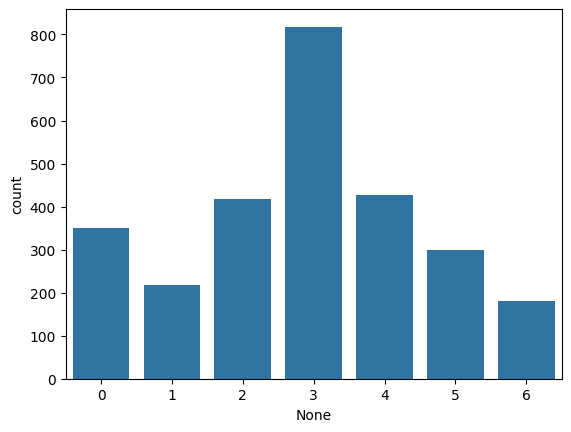

In [8]:
topic_counts = pd.Series(data. y. numpy()).value_counts().sort_index()
sns.barplot(x=topic_counts.index , y=topic_counts)

# **TF-IDF Model**

In [9]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier


X_binary = data.x.numpy()
y = data.y.numpy()

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy() #Training Research Papers
val_idx = data.val_mask.numpy() #Validation Research Papers
test_idx = data.test_mask.numpy() ##Testing Research Papers

X_train , y_train = X_baseline[train_idx] , y[train_idx]
X_test , y_test = X_baseline[test_idx] , y[test_idx]

rf = RandomForestClassifier(n_estimators=100 ,max_features="sqrt" , class_weight="balanced" , random_state=42 , n_jobs=-1)

rf.fit(X_train , y_train)
rf_pred = rf.predict(X_test)


<Axes: >

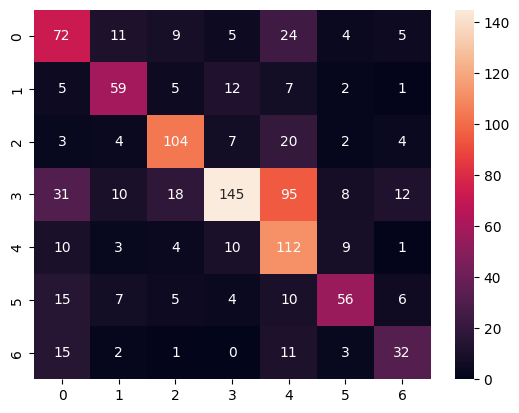

In [10]:
from sklearn.metrics import accuracy_score , f1_score , confusion_matrix

#Accuracy=Out of all pred,How  many will correct
#F1 : Balance between Precision and recall
accuracy = accuracy_score(y_test , rf_pred)
f1 = f1_score(y_test, rf_pred, average='weighted')

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')

# **Advanced Model:-A simple two layer GCN**

# GCN updates each paper by combining its own features with informative from neighbouring papers

In [11]:
#Library:Pytorch & Module:nn
from torch import nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch
from torch import nn, optim

class SimpleGCN(nn.Module):
  def __init__(self , input_dim , hidden_dim , output_dim , dropout=0.5):
    super().__init__()

    #Creating 2 GCN Layer
    self.conv1 = GCNConv(input_dim , hidden_dim)
    self.conv2 = GCNConv(hidden_dim , output_dim)
    self.dropout = dropout

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = F.relu(x)
    x = F.dropout(x , p=self.dropout , training=self.training)
    x = self.conv2(x , edge_index)
    return x

model = SimpleGCN(input_dim=data.num_features ,hidden_dim = 32 , output_dim=dataset.num_classes,)

optimizer = torch.optim.Adam(model.parameters(), lr=0.1 , weight_decay=5e-4)
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [12]:
X_binary = data.x.numpy()
y = data.y.numpy()

#Reweight the supplies word indicators
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()

#Training of GCN Model
def train_one_epoch():
    model.train()
    #gradient=0 as calculate gradient in each steps
    optimizer .zero_grad()
    #Raw score for each class nodes by features+edges
    logits = model(data.x, data.edge_index)
    #Whats different our pred from actual answer by taking pred of training paper only
    loss = F.cross_entropy(logits[data.train_mask] ,data.y[data.train_mask])
    #Back Propagation
    loss.backward()
    #weight Update
    optimizer.step()
    #.item() tensor->values
    return loss.item()

#evaluation
@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x , data.edge_index)
    pred = logits.argmax(dim=1)
    accuracy = (pred[mask] == data.y[mask]).float().mean().item()
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        pred[mask].numpy(),
        average= "macro"
    )

    return accuracy , macro_f1 , pred

In [13]:
losses , train_accuracies , val_accuracies =[] ,[] , []
best_val_accuracy = 0.0
best_state = None
patience = 20
epoch_without_improvement = 0

for epoch in range(1,201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy)

  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_state = model.state_dict(
    )

  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

if epoch == 1 or epoch % 10 == 0:
  print(f"Epoch: {epoch:03d} | Loss:{loss:.4f} | Train acc:{train_accuracy:4f} | Val acc:{val_accuracy:4f} | Best Val acc:{best_val_accuracy:.4f}")

model.load_state_dict(best_state)
gcn_accuracy , gcn_f1 , gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy : {gcn_accuracy:.3f}")
print(f"GCN test macro-f1 : {gcn_f1:.3f}")

Early stopping at epoch 24

GCN test accuracy : 0.803
GCN test macro-f1 : 0.799


# Compare the Models

<Axes: >

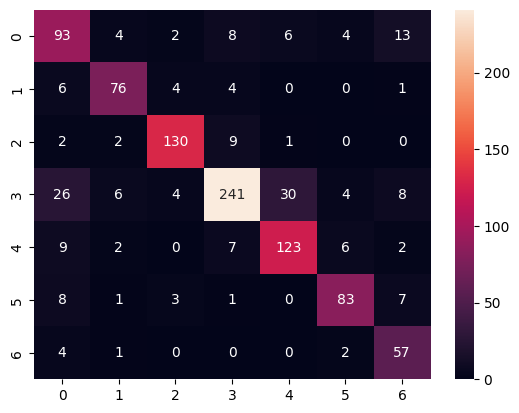

In [14]:
#Confusion MArix for GCN model.
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(), gcn_pred[data.test_mask].numpy()),
    annot=True,
    fmt="d"
)

In [15]:
from sklearn.metrics import accuracy_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="macro")

gcn_true = data.y.cpu().numpy()
gcn_accuracy = accuracy_score(gcn_true, gcn_pred)
gcn_f1 = f1_score(gcn_true, gcn_pred, average="macro")

results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro-F1": [rf_f1, gcn_f1]
})

print(results)

           Model  Accuracy  Macro-F1
0  Random Forest  0.580000  0.581814
1            GCN  0.797267  0.794330


In [16]:
%pip install -U protobuf==6.31.1 onnx==1.23.0 onnxscript==0.7.2

In [17]:
%pip install --force-reinstall protobuf==6.31.1

  Using cached protobuf-6.31.1-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
Using cached protobuf-6.31.1-cp39-abi3-manylinux2014_x86_64.whl (321 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [18]:
#ONNX -> Open Neural Network Exchange -> Model very fast and optimized.
import torch
%pip install onnxscript

#set the model to evaluation mode
model.eval()

#Create dummy input for ONNX export
#The input 'x' has shape [num_nodes, num_features]
#The input 'edge_index' has sahpe[2, edge_index]

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    model,
    #1. Trained Model.
    (x_dummy, edge_index_dummy),
    #2. Model input.
    onnx_file_path,
    #3. Where to save the ONNX model.
    export_params = True,
    #4. Store the trained parameter weights inside the model file.
    opset_version=18,
    #5. Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding=True,
    #6.Whether to execute constant folding for optimation
    input_names=['node_features', 'edge_indices'],
    #7. input names
    output_names=['logits'],
    #8. Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},
        #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}
        #10.Variable length for num_edges
    }
)
print(f"Model exported to {onnx_file_path}")

/tmp/ipykernel_23154/4156896082.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to simple_gcn_cora.onnx
